# Practical 11 — LangGraph Conditional Workflow (Amazon Nova / Bedrock)

**Goal:** a LangGraph workflow with a classifier node that routes each
query down a **SQL agent path** or a **RAG agent path**, a graceful
**error node**, and a graph visualized with `.get_graph().draw_mermaid()`.


## Setup the configuration


In [ ]:
# Installs everything listed in requirements.txt at the project root.
# %pip install -q -r ../requirements.txt


In [1]:
import os
import boto3

# Ensure Python looks at your configured credentials
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

# Test the connection directly in Python
try:
    client = boto3.client("sts")
    print(f"Success! Authenticated as: {client.get_caller_identity()['Arn']}")
except Exception as e:
    print(f"Authentication failed: {e}")


Success! Authenticated as: arn:aws:iam::378311506052:user/Master_05


In [2]:
"""
Notebook setup: make the project root importable, and load credentials
from .env.
"""
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

has_aws = bool(
    os.environ.get("AWS_BEARER_TOKEN_BEDROCK") or os.environ.get("AWS_ACCESS_KEY_ID")
)
if not has_aws:
    print(
        "WARNING: no AWS Bedrock credentials found. Copy .env.example to "
        ".env at the project root and add either AWS_BEARER_TOKEN_BEDROCK "
        "or an AWS_ACCESS_KEY_ID/AWS_SECRET_ACCESS_KEY pair before running "
        "Section 4 (graph construction and visualization in Section 3 "
        "work fine without it -- only actually *running* a query needs "
        "real credentials)."
    )
else:
    print("AWS Bedrock credentials loaded -- ready to go.")

AWS Bedrock credentials loaded -- ready to go.


In [3]:
from src.agents import classify_query_node, rag_agent_node, sql_agent_node, error_node

for fn in [classify_query_node, rag_agent_node, sql_agent_node, error_node]:
    print(f"{fn.__name__}: {fn.__doc__.strip().splitlines()[0]}")

classify_query_node: Classify the incoming query as needing SQL, RAG, or UNKNOWN handling.
rag_agent_node: Attempt to answer the query using the document knowledge base.
sql_agent_node: Attempt to answer the query by generating and safely executing SQL.
error_node: Produce a graceful, user-facing message when no path could answer.


### The sample data sources

- **SQL side:** `config/db_init.py` builds a small local SQLite database
  (`data/company_sample.db`, gitignored, regenerated automatically) with
  `employees` and `products` tables.
- **RAG side:** `data/sample_docs/company_policies.txt` — company handbook
  text, indexed into FAISS (with Titan embeddings) by
  `src/agents/rag_agent.py`.


In [4]:
from config.db_init import ensure_sample_database
from utils.helpers import execute_readonly_query

ensure_sample_database()
columns, rows = execute_readonly_query(
    "SELECT department, COUNT(*) AS headcount, AVG(salary) AS avg_salary "
    "FROM employees GROUP BY department"
)
print(columns)
for row in rows:
    print(row)

['department', 'headcount', 'avg_salary']
('Engineering', 3, 96666.66666666667)
('Marketing', 2, 69500.0)
('Sales', 2, 68500.0)
('Support', 1, 55000.0)


In [5]:
# Safety check -- execute_readonly_query must reject anything that isn't a
# single SELECT statement, since it will receive LLM-generated SQL
# (untrusted input) from sql_agent.py.
for unsafe_sql in [
    "DROP TABLE employees",
    "DELETE FROM employees WHERE id = 1",
    "SELECT * FROM employees; DROP TABLE employees;",
]:
    try:
        execute_readonly_query(unsafe_sql)
        print("SAFETY FAILURE for:", unsafe_sql)
    except ValueError as e:
        print(f"Correctly blocked -> {unsafe_sql!r}: {e}")

Correctly blocked -> 'DROP TABLE employees': Only single SELECT statements are allowed.
Correctly blocked -> 'DELETE FROM employees WHERE id = 1': Only single SELECT statements are allowed.
Correctly blocked -> 'SELECT * FROM employees; DROP TABLE employees;': Multiple statements are not allowed.


## Building and visualizing the graph

`src/graph/workflow.py` wires the four agents and three conditional edges
together into a compiled `StateGraph`. Building and compiling the graph is
pure Python — it doesn't call any model, so this section works even before
your AWS credentials are confirmed working.


In [6]:
from src.graph.workflow import build_graph

compiled_graph = build_graph()
print("Graph compiled:", type(compiled_graph).__name__)
print("Nodes:", list(compiled_graph.get_graph().nodes.keys()))

Graph compiled: CompiledStateGraph
Nodes: ['__start__', 'classify_query', 'rag_agent', 'sql_agent', 'error_node', '__end__']


### Mermaid source (`draw_mermaid()`)



In [7]:
mermaid_source = compiled_graph.get_graph().draw_mermaid()
print(mermaid_source)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify_query(classify_query)
	rag_agent(rag_agent)
	sql_agent(sql_agent)
	error_node(error_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify_query;
	classify_query -.-> rag_agent;
	classify_query -.-> sql_agent;
	rag_agent -. &nbsp;end&nbsp; .-> __end__;
	rag_agent -.-> sql_agent;
	sql_agent -. &nbsp;end&nbsp; .-> __end__;
	sql_agent -.-> error_node;
	error_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Rendered image — for your screenshot/commit step


Saved via draw_mermaid_png() (via the Mermaid.Ink API -- needs internet) -> /Users/pateljay/Documents/GenAI/Practical_11_langgraph_conditional_workflow/graph_workflow.png


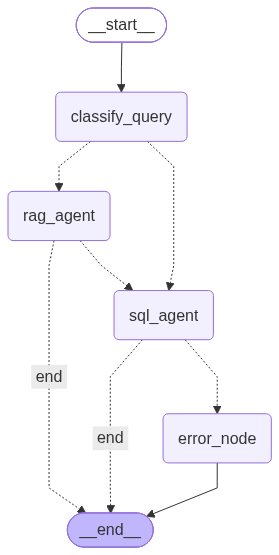

In [8]:
from IPython.display import Image, display

SCREENSHOT_PATH = PROJECT_ROOT / "graph_workflow.png"

try:
    png_bytes = compiled_graph.get_graph().draw_png()
    method = "draw_png() (local, via pygraphviz/graphviz)"
except Exception:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
        method = "draw_mermaid_png() (via the Mermaid.Ink API -- needs internet)"
    except Exception as e:
        png_bytes = None
        print(
            "Neither draw_png() nor draw_mermaid_png() worked in this "
            f"environment ({e}).\nPaste the Mermaid source from the cell "
            "above into https://mermaid.live, then save a manual "
            f"screenshot to:\n  {SCREENSHOT_PATH}"
        )

if png_bytes is not None:
    with open(SCREENSHOT_PATH, "wb") as f:
        f.write(png_bytes)
    print(f"Saved via {method} -> {SCREENSHOT_PATH}")
    display(Image(png_bytes))


## 3. Running the workflow

Four queries, each chosen to exercise a different path through the graph:

| # | Query | Expected path |
|---|---|---|
| 1 | *"How many employees work in the Engineering department, and what's their average salary?"* | classifier → **sql_agent** → success → END |
| 2 | *"What is the company's policy on remote work?"* | classifier → **rag_agent** → success → END |
| 3 | *"Tell me about Ethan Wright."* | classifier → rag_agent → **no relevant policy text found** → falls back to **sql_agent** → success → END |
| 4 | *"What's the weather like in Tokyo today?"* | classifier → rag_agent → fails → sql_agent → **also fails** → **error_node** |


In [9]:
def run_and_report(query: str):
    """Invoke the compiled graph on one query and print a readable summary."""
    result = compiled_graph.invoke({"query": query})
    print(f"QUERY: {query}")
    print(f"  query_type   : {result.get('query_type')}")
    print(f"  rag_success  : {result.get('rag_success')}")
    print(f"  sql_success  : {result.get('sql_success')}")
    print(f"  answered by  : {result.get('source')}")
    print(f"  ANSWER       : {result.get('answer')}")
    print("-" * 80)
    return result

In [10]:
result_1 = run_and_report(
    "How many employees work in the Engineering department, and what's their average salary?"
)


QUERY: How many employees work in the Engineering department, and what's their average salary?
  query_type   : sql
  rag_success  : None
  sql_success  : True
  answered by  : sql
  ANSWER       : There are 3 employees working in the Engineering department, and their average salary is $96,666.67.
--------------------------------------------------------------------------------


In [11]:
result_2 = run_and_report("What is the company's policy on remote work?")


QUERY: What is the company's policy on remote work?
  query_type   : rag
  rag_success  : False
  sql_success  : False
  answered by  : error
  ANSWER       : I wasn't able to answer that confidently using either the knowledge base or the database. (The generated query ran but returned no rows.) Try rephrasing the question, or ask something more specific to company policies (for the knowledge base) or employees/products (for the database).
--------------------------------------------------------------------------------


In [12]:
result_3 = run_and_report("Tell me about Ethan Wright.")


QUERY: Tell me about Ethan Wright.
  query_type   : sql
  rag_success  : None
  sql_success  : True
  answered by  : sql
  ANSWER       : Ethan Wright is an employee in the Engineering department. He earns a salary of $105,000 and was hired in the year 2017. His employee ID is 6.
--------------------------------------------------------------------------------


In [13]:
result_4 = run_and_report("What's the weather like in Tokyo today?")


QUERY: What's the weather like in Tokyo today?
  query_type   : unknown
  rag_success  : False
  sql_success  : False
  answered by  : error
  ANSWER       : I wasn't able to answer that confidently using either the knowledge base or the database. (SQL generation/execution failed: Only single SELECT statements are allowed.) Try rephrasing the question, or ask something more specific to company policies (for the knowledge base) or employees/products (for the database).
--------------------------------------------------------------------------------


**What to check across the four runs above:** run 1 and 2 should each
be answered directly (`source` = `"sql"` / `"rag"`); run 3 should show
`rag_success: False` followed by `sql_success: True` and `source: "sql"` —
proof the fallback edge fired; run 4 should show both flags `False` and
`source: "error"`, with the graceful message from `error_node`.


In [14]:
import subprocess

result = subprocess.run(["pytest", "-v"], cwd=str(PROJECT_ROOT), capture_output=True, text=True)
print(result.stdout[-3000:])
print("Exit code:", result.returncode)


SED [ 62%]
tests/test_setup_services.py::TestLlmInvoke::test_invoke_chat_returns_the_models_content_field PASSED [ 64%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_valid_select_returns_rows PASSED [ 66%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_select_with_trailing_semicolon_is_allowed PASSED [ 68%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_non_select_statements_are_rejected[DROP TABLE employees] PASSED [ 71%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_non_select_statements_are_rejected[DELETE FROM employees WHERE id = 1] PASSED [ 73%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_non_select_statements_are_rejected[UPDATE employees SET salary = 0] PASSED [ 75%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_non_select_statements_are_rejected[INSERT INTO employees VALUES (99, 'x', 'x', 1, 2020)] PASSED [ 77%]
tests/test_sql_agent.py::TestExecuteReadonlyQuery::test_non_select_statements_are_rejected[ATTACH DATABASE 